In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Optimal_transport as OT
from scipy.optimize import minimize

def Gradient(x0,f,h=1e-2):
    
    '''
    Approximate the Gradient vector of f at x0 using finite differences, knowing the value of f at every point of the domain

    x0: n-vecteur containing the parameter value at which the hessian should be evaluated

    f: Function that return a value for a list of parameter x


    '''

    dim=f.__code__.co_argcount
    Gradient=np.zeros((dim))    
    for i in range(dim):
            Gradient[i]= (f(*(x0+np.array([h/2 if k == i else 0 for k in range(dim)])))
                        -f(*(x0-np.array([h/2 if k == i else 0 for k in range(dim)]))))/h
      
    return Gradient


def steepest_descent(X0,f,num_iter_max=100,eps=1e-3,Xmin=[0,0],Xmax=[1,1],eta=1e-3,h=1e-2):
    """
    Compute the steepest descent algorithm
    
    Parameters
    ----------
    
    X0: array, starting position
    f: function to be minimised 
    num_iter_max: int, maximum number of iteration
    eps: float, precision for the final result
    Xmin: array, minimum bounds
    Xmax: array, maximum bounds
    eta: float, learning rate
    h: float, gradient evaluation precision
    
    
    Returns
    -------
    
    X: Final position
    Err: list of all errors from X0 to X
    Xs: list of all positions from X0 to X
    
    """
    
    dim=f.__code__.co_argcount

    X=X0
    Xs=[X0]
    Err=[]
    for i in range(num_iter_max):
        
        if all(list(map(lambda x,y,z : x>=y and x<=z, X,Xmin,Xmax))):
            Err.append(f(*X))
            
            dk=-1*eta*Gradient(X,f,h)
            if np.sum(abs(dk))<=eps:
                print('Descent finished')
                break
            X=X+dk
            Xs.append(X)
        else:
            Err.append(f(*X))
            print('X got out of bound')
            break
        if i==num_iter_max-1:
            print('Maximum number of iteration reached')
    return np.array(X),np.array(Err),np.array(Xs)

    
    
# Analytical solution of Welty (1994)



def diverging(t,alpha,R,Q,Phi,L,M=1,rho=1000):
        
    """
    Compute the Concentration of a tracer in a well in diverging radial flow a single injection according to Welty 1994
    
    Parameters
    ----------
    
    t: float, time at which the concentration is observed
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    float, concentration in the well at t
    
    """
    
    tc=t/(R**2 *np.pi*Phi*L/Q)
    e=-1*(1-tc)**2/((16*alpha*tc**1.5)/(3*R))
    denom=np.sqrt(tc**1.5)
    c_norm=np.nan_to_num(np.exp(e)/denom)
    return c_norm*M/(rho*2*np.pi*Phi*L*(R**2)*np.sqrt(4*np.pi*alpha/(3*R)))


def multipeaks(times,t_start,alpha,R,Q,Phi,L,M=1,rho=1000): 
    """
    Compute the Concentration of a tracer in a well in diverging radial flow with multiple injections according to Welty 1994
    
    Parameters
    ----------
    
    times: List or numpy Array, contains the time steps
    t_start: List or numpy Array, contains the starting times of all the injections
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    List or numpy Array, contains the concentration in the well for every time steps of t
    
    """
    
    res=np.zeros(len(times))
    for k in range(len(t_start)):
        t=times-t_start[k]
        res[t>0]+=diverging(t[t>0],alpha,R,Q,Phi,L,M=M,rho=rho)
    return res







alpha_target=1
phi_target=0.15

seconds_in_day=3600*24
times=np.linspace(100,seconds_in_day*100,200)
cs_target=multipeaks(times,[0,20*seconds_in_day],alpha=alpha_target,R=220,Q=10000/1000/60,Phi=phi_target,L=20)



In [2]:
def add_noise(ts,std_dev,mean=0):

    noise = np.random.normal(mean, std_dev, ts.shape)
    noisy_ts = ts + noise

    return np.clip(noisy_ts,0,None)

def gen_c_noise(std_days,std_conc):
    random_time_shift1=(np.random.random()-0.5)*seconds_in_day*std_days*2
    random_time_shift2=(np.random.random()-0.5)*seconds_in_day*std_days*2
    cs_noise=add_noise(multipeaks(times,[0+random_time_shift1,20*seconds_in_day+random_time_shift2],alpha=alpha_target,
                                R=220,Q=10000/1000/60,Phi=phi_target,L=20),
                                std_dev=std_conc)
    return cs_noise


In [3]:
import numpy as np
from scipy.optimize import minimize
from joblib import Parallel, delayed

def f_L2(x, cs_noise):
    alpha_n, phi_n = x
    alpha = 10**(alpha_n * 2 - 1)
    phi = 10**(phi_n - 1.3)
    cs = multipeaks(times, [0, 20 * seconds_in_day], alpha=alpha, R=220, Q=10000 / 1000 / 60, Phi=phi, L=20)
    
    return np.sum(((cs - cs_noise) / np.max(cs_noise)) ** 2)




def f_WD(x, cs_noise):

    """
    Objective fonction using Wasserstein distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, Wasserstein distance error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_noise,times,cs,reg=1)/np.max(cs_noise) 

def f_Sinkhorn(x, cs_noise):
    """
    Objective fonction using Sinkhorn distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, Sinkhorn error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_noise,times,cs,Sinkhorn_dist=True,reg=1,logeps=3,NumIterMax=200,k1=.2,k2=1)/np.max(cs_target)

In [ ]:
def recuit_simule_hybride(fonction, bornes, cs_noise, n_iterations=2000, temp_initiale=1, alpha=0.98, taille_pas=0.1):
    b_min, b_max = np.array(bornes)[:, 0], np.array(bornes)[:, 1]
    
    etat_actuel = b_min + np.random.rand(2) * (b_max - b_min)
    score_actuel = fonction(etat_actuel, cs_noise) # <-- Passage de cs_noise
    
    meilleur_etat = etat_actuel.copy()
    meilleur_score = score_actuel
    
    t = temp_initiale
    historique = [etat_actuel.copy()]
    
    for i in range(n_iterations):
        bruit = np.random.normal(0, taille_pas, size=2)
        candidat = np.clip(etat_actuel + bruit, b_min, b_max)
        score_candidat = fonction(candidat, cs_noise) # <-- Passage de cs_noise
        meilleur_score = score_candidat
        meilleur_estado = candidat.copy()        
        diff = score_candidat - score_actuel
        if diff < 0 or np.random.rand() < np.exp(-diff / t):
            etat_actuel, score_actuel = candidat, score_candidat
            historique.append(etat_actuel.copy())
            if score_candidat < meilleur_score:
                meilleur_score = score_candidat
                meilleur_estado = candidat.copy()
                
        t = t * alpha

    # Utilisation de args=(cs_noise,) pour que scipy le transmette à f_L2
    res = minimize(
        fonction, 
        x0=meilleur_estado, 
        bounds=bornes, 
        args=(cs_noise,), # <-- Indispensable pour Nelder-Mead
        method='Nelder-Mead',
        options={'xatol': 1e-6, 'fatol': 1e-6} 
    )
    
    historique.append(res.x)
    return res.x, res.fun, np.array(historique)


In [5]:
import numpy as np
from joblib import Parallel, delayed

def executer_iteration(i):
    # Génération du bruit unique pour cette itération
    cs_noise_local = gen_c_noise(1, 1e-10)
    
    # Exécution des recuits avec le bruit local en argument
    meilleure_position_L2, _, _ = recuit_simule_hybride(f_L2, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=10)
    meilleure_position_WD, _, _ = recuit_simule_hybride(f_WD, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=0.5)
    meilleure_position_Sinkhorn, _, _ = recuit_simule_hybride(f_Sinkhorn, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=10)
    
    return meilleure_position_L2, meilleure_position_WD, meilleure_position_Sinkhorn

# Lancement des 500 simulations en parallèle
resultats = Parallel(n_jobs=6, verbose=10)(
    delayed(executer_iteration)(i) for i in range(500)
)

# Séparation des résultats et conversion en Tableaux NumPy
BEST_L2, BEST_WD,BEST_SINKHORN = zip(*resultats)
BEST_L2 = np.array(BEST_L2)
BEST_WD = np.array(BEST_WD)
BEST_SINKHORN=np.array(BEST_SINKHORN)

np.save('res/best_L2_1days',BEST_L2)
np.save('res/best_WD_1days',BEST_WD)
np.save('res/best_SINKHORN_1days',BEST_SINKHORN)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  9.6min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  9.7min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 30.1min
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed: 40.3min
[Parallel(n_jobs=6)]: Done  29 tasks      | elapsed: 50.7min
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed: 71.1min
[Parallel(n_jobs=6)]: Done  49 tasks      | elapsed: 91.3min
[Parallel(n_jobs=6)]: Done  60 tasks      | elapsed: 101.9min
[Parallel(n_jobs=6)]: Done  73 tasks      | elapsed: 131.9min
[Parallel(n_jobs=6)]: Done  86 tasks      | elapsed: 152.3min
[Parallel(n_jobs=6)]: Done 101 tasks      | elapsed: 172.7min
[Parallel(n_jobs=6)]: Done 116 tasks      | elapsed: 202.5min
[Parallel(n_jobs=6)]: Done 133 tasks      | elapsed: 232.5min
[Parallel(n_jobs=6)]: Done 150 tasks      | elapsed: 253.5min
[Parallel(n_jobs=6)]: Done 169 tasks      | elapsed: 292.7min
[P

UnboundLocalError: cannot access local variable 'meilleur_estado' where it is not associated with a value

In [ ]:
import numpy as np
from joblib import Parallel, delayed

def executer_iteration(i):
    # Génération du bruit unique pour cette itération
    cs_noise_local = gen_c_noise(4, 1e-10)
    
    # Exécution des recuits avec le bruit local en argument
    meilleure_position_L2, _, _ = recuit_simule_hybride(f_L2, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=10)
    meilleure_position_WD, _, _ = recuit_simule_hybride(f_WD, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=0.5)
    meilleure_position_Sinkhorn, _, _ = recuit_simule_hybride(f_Sinkhorn, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=10)
    
    return meilleure_position_L2, meilleure_position_WD, meilleure_position_Sinkhorn

# Lancement des 500 simulations en parallèle
resultats = Parallel(n_jobs=6, verbose=10)(
    delayed(executer_iteration)(i) for i in range(500)
)

# Séparation des résultats et conversion en Tableaux NumPy
BEST_L2, BEST_WD,BEST_SINKHORN = zip(*resultats)
BEST_L2 = np.array(BEST_L2)
BEST_WD = np.array(BEST_WD)
BEST_SINKHORN=np.array(BEST_SINKHORN)

np.save('res/best_L2_4days',BEST_L2)
np.save('res/best_WD_4days',BEST_WD)
np.save('res/best_SINKHORN_4days',BEST_SINKHORN)

In [ ]:
times=np.linspace(100,seconds_in_day*100,30)

import numpy as np
from joblib import Parallel, delayed

def executer_iteration(i):
    # Génération du bruit unique pour cette itération
    cs_noise_local = gen_c_noise(2, 1e-10)
    
    # Exécution des recuits avec le bruit local en argument
    meilleure_position_L2, _, _ = recuit_simule_hybride(f_L2, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=10)
    meilleure_position_WD, _, _ = recuit_simule_hybride(f_WD, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=0.5)
    meilleure_position_Sinkhorn, _, _ = recuit_simule_hybride(f_Sinkhorn, [[0, 1], [0, 1]], cs_noise=cs_noise_local, temp_initiale=10)
    
    return meilleure_position_L2, meilleure_position_WD, meilleure_position_Sinkhorn

# Lancement des 500 simulations en parallèle
resultats = Parallel(n_jobs=6, verbose=10)(
    delayed(executer_iteration)(i) for i in range(500)
)

# Séparation des résultats et conversion en Tableaux NumPy
BEST_L2, BEST_WD,BEST_SINKHORN = zip(*resultats)
BEST_L2 = np.array(BEST_L2)
BEST_WD = np.array(BEST_WD)
BEST_SINKHORN=np.array(BEST_SINKHORN)

np.save('res/best_L2_less_points',BEST_L2)
np.save('res/best_WD_less_points',BEST_WD)
np.save('res/best_SINKHORN_less_point',BEST_SINKHORN)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   29.1s remaining:   58.3s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   29.2s remaining:   29.2s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   29.3s remaining:   14.6s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   29.4s remaining:    0.0s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   29.4s finished


In [ ]:
import os
os.system("shutdown /s /t 60")

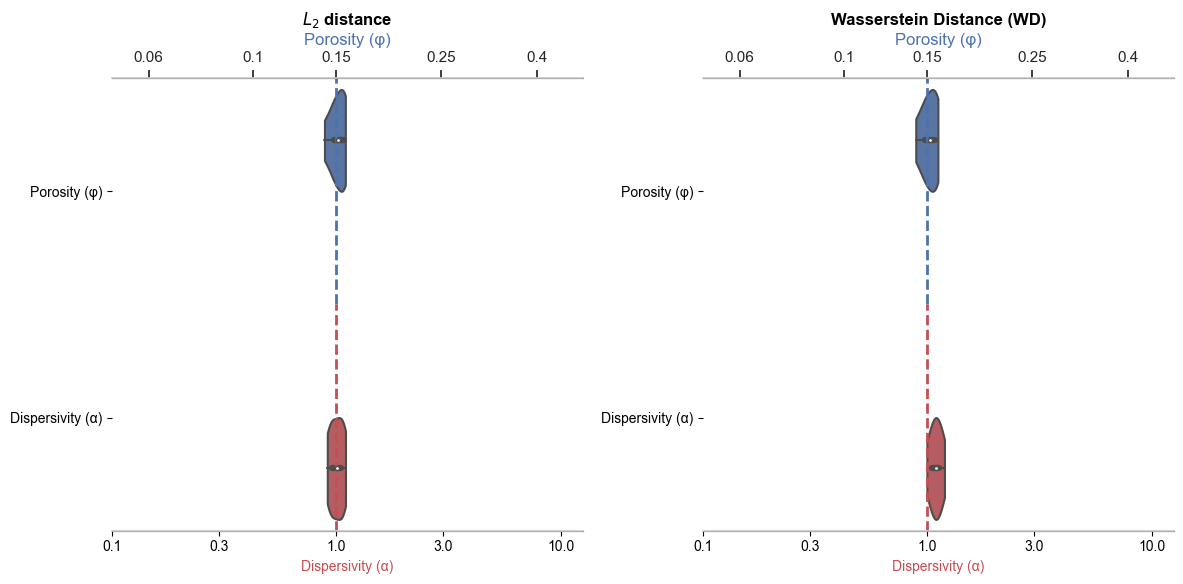

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


fig, (ax_l2, ax_wd) = plt.subplots(1, 2, figsize=(12, 6))
sns.set_theme(style="whitegrid", context="notebook")

alpha_line = 0.5
phi_line = 0.5

facteur_echelle_phi = 0.5 / (1.3 + np.log10(0.15))

phi_ticks_physiques = [0.06, 0.1, 0.15, 0.25, 0.4]
phi_ticks_graphique = [
    (1.3 + np.log10(val)) * facteur_echelle_phi for val in phi_ticks_physiques
]

alpha_ticks_physiques = [0.1, 0.3, 1.0, 3.0, 10.0]
alpha_ticks_graphique = [
    (np.log10(val) + 1) / 2 for val in alpha_ticks_physiques
]


df_l2 = pd.DataFrame(
    {
        "Valeurs": np.concatenate(
            [BEST_L2[:, 1] * facteur_echelle_phi, BEST_L2[:, 0]]
        ),
        "Paramètre": ["Porosity (φ)"] * len(BEST_L2)
        + ["Dispersivity (α)"] * len(BEST_L2),
    }
)

df_wd = pd.DataFrame(
    {
        "Valeurs": np.concatenate(
            [BEST_WD[:, 1] * facteur_echelle_phi, BEST_WD[:, 0]]
        ),
        "Paramètre": ["Porosity (φ)"] * len(BEST_WD)
        + ["Dispersivity (α)"] * len(BEST_WD),
    }
)


sns.violinplot(
    data=df_l2,
    x="Valeurs",
    y="Paramètre",
    ax=ax_l2,
    hue="Paramètre",
    legend=False,
    palette={"Porosity (φ)": "#4C72B0", "Dispersivity (α)": "#C44E52"},
    width=0.9,
    density_norm="width",
    cut=0,
)

ax_l2.axvline(
    phi_line, ymin=0.5, ymax=1.0, color="#4C72B0", linestyle="--", linewidth=2
)
ax_l2.axvline(
    alpha_line, ymin=0.0, ymax=0.5, color="#C44E52", linestyle="--", linewidth=2
)


ax_l2.set_xlim(0, 1.05)
ax_l2.set_xticks(alpha_ticks_graphique)
ax_l2.set_xticklabels([str(v) for v in alpha_ticks_physiques])
ax_l2.set_title("$L_2$ distance", weight="bold")
ax_l2.set_xlabel("Dispersivity (α)", color="#C44E52")
ax_l2.set_ylabel("")


ax_l2_top = ax_l2.twiny()
ax_l2_top.set_xlim(ax_l2.get_xlim())
ax_l2_top.set_xticks(phi_ticks_graphique)
ax_l2_top.set_xticklabels([str(v) for v in phi_ticks_physiques])
ax_l2_top.set_xlabel("Porosity (φ)", color="#4C72B0")
ax_l2_top.grid(False)



sns.violinplot(
    data=df_wd,
    x="Valeurs",
    y="Paramètre",
    ax=ax_wd,
    hue="Paramètre",
    legend=False,
    width=0.9,
    density_norm="width",
    palette={"Porosity (φ)": "#4C72B0", "Dispersivity (α)": "#C44E52"},
    cut=0,
)

ax_wd.axvline(
    phi_line, ymin=0.5, ymax=1.0, color="#4C72B0", linestyle="--", linewidth=2
)
ax_wd.axvline(
    alpha_line, ymin=0.0, ymax=0.5, color="#C44E52", linestyle="--", linewidth=2
)


ax_wd.set_xlim(0, 1.05)
ax_wd.set_xticks(alpha_ticks_graphique)
ax_wd.set_xticklabels([str(v) for v in alpha_ticks_physiques])
ax_wd.set_title("Wasserstein Distance (WD)", weight="bold")
ax_wd.set_xlabel("Dispersivity (α)", color="#C44E52")
ax_wd.set_ylabel("")


ax_wd_top = ax_wd.twiny()
ax_wd_top.set_xlim(ax_wd.get_xlim())
ax_wd_top.set_xticks(phi_ticks_graphique)
ax_wd_top.set_xticklabels([str(v) for v in phi_ticks_physiques])
ax_wd_top.set_xlabel("Porosity (φ)", color="#4C72B0")
ax_wd_top.grid(False)
if ax_l2.get_legend() is not None:
    ax_l2.get_legend().remove()
if ax_wd.get_legend() is not None:
    ax_wd.get_legend().remove()

sns.despine(left=True, top=False)
plt.tight_layout()
plt.show()
